# WalkIn Redemption Classifier — Standalone / Google Colab Edition

This is a self-contained copy of the original `research_notebook.ipynb` from the WalkIn
project, extracted so it can run independently of the full application repository — e.g.
cloned straight into Google Colab. It runs the **exact same pipeline**
(`train_redemption_classifier.py`, unmodified except for two path lines) against a frozen
snapshot of the real research dataset (583 Walnut Creek, CA businesses / 4,091 deals / 25,172
`location_popularity` rows), loaded into a local SQLite file — no Postgres, no API keys, no
access to the rest of the codebase required.

**First time here?** Just run the cell below, then continue through the notebook normally.
See `README.md` in this folder for more detail on how this package was produced.

In [ ]:
# We start with a clean up code for the /content directory (incase we need to rerun after the first)
! rm -rf *
! ls -la

In [ ]:
# --- One-time setup: clone repo (Colab only), install dependencies, rebuild the local database ---
# Safe to re-run; build_local_db.py rebuilds walkin_research.db from data/*.csv every time.
import os, sys, shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not os.path.exists("build_local_db.py"):
    # Opening this notebook via Colab's GitHub integration only loads the .ipynb file
    # itself -- the kernel's working directory (/content) starts empty, with none of the
    # supporting files (data/, app/, build_local_db.py, train_redemption_classifier.py)
    # present. Clone the repo, then hoist its contents up a level into the working
    # directory (instead of %cd-ing into it)
    REPO_URL = "https://github.com/mattybell/Walkin-csv-only.git"
    REPO_BRANCH = "main"
    REPO_DIR = "Walkin-csv-only"
    !git clone -q -b {REPO_BRANCH} {REPO_URL}
    for name in os.listdir(REPO_DIR):
        if name == ".git":
            continue
        src, dst = os.path.join(REPO_DIR, name), name
        if os.path.exists(dst):
            shutil.rmtree(dst) if os.path.isdir(dst) else os.remove(dst)
        shutil.move(src, dst)
    shutil.rmtree(REPO_DIR)

if IN_COLAB:
    %pip install -q -r requirements.txt

os.environ["DATABASE_URL"] = "sqlite:///./walkin_research.db"
!python build_local_db.py

# WalkIn Redemption Classifier — Experimental Setup & Results

This notebook executes the same pipeline as `backend/scripts/train_redemption_classifier.py`
end-to-end, cell by cell, so every number and figure in `research_report.md` /
`research_report.pdf` is reproduced live rather than only described. It imports the
pipeline's functions directly from the script (single source of truth for the algorithms)
and runs the orchestration here, with real output rendered inline after each stage.

**Reproducibility:** every source of randomness is seeded (`RANDOM_SEED = 42`); re-running
this notebook end-to-end reproduces the exact metrics reported in the paper.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss

import train_redemption_classifier as trc

%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
from app.db.session import SessionLocal

print("Loaded pipeline module from:", trc.__file__)
print("RANDOM_SEED =", trc.RANDOM_SEED)


Loaded pipeline module from: /Users/mccool/projects/shool/WalkIn/V9/backend/scripts/train_redemption_classifier.py
RANDOM_SEED = 42


## 1. Load Source Data

Read-only against `Business`, `Deal`, and `LocationPopularity` — this notebook never writes
to the production database. Businesses come from the Google Places API (583 real Walnut
Creek, CA merchants, grown from an initial 166 via a second import pass weighted toward
restaurant/bar categories); deals were seeded by `backend/scripts/seed_walnut_creek_deals.py`
(one of each of the 7 deal types per business); foot-traffic rows come from BrightData's
real Datasets API (329 of 583 businesses have coverage; the remaining 254 have no published
Google popular-times signal — see the report's Data Analysis section).


In [2]:
db = SessionLocal()
businesses, deals, popularity = trc.load_source_data(db)

print(f"Businesses: {len(businesses)}")
print(f"Active deals: {len(deals)}")
print(f"location_popularity rows: {len(popularity)}")

pd.DataFrame([{"category": b.category, "rating": b.rating, "rating_count": b.rating_count}
              for b in businesses]).describe(include="all").T


Businesses: 583
Active deals: 4091
location_popularity rows: 25172


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
category,582,14,hair_care,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,571.0,NaN,NaN,NaN,4.507531,0.380022,1.0,4.3,4.5,4.8,5.0
rating_count,583.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Foot-Traffic Lookup (3-Tier Fallback)

Only 329 of 583 businesses (56.4%) have any real BrightData popularity data, so an exact
`(business, hour, day-of-week)` join would return null for the other 43.6% of businesses
entirely. `PopularityLookup` falls back from the exact triple, to `(business, hour)`, to a
per-business average, to a constant 50.0.


In [3]:
popularity_lookup = trc.PopularityLookup(popularity)

# Sanity check: how many (business, hour, day-of-week) combinations actually have an exact match?
exact_keys = {(p.business_id, p.hour_of_day, p.day_of_week) for p in popularity}
sample_biz = businesses[0]
print(f"Exact-tier keys available (out of a possible {len(businesses)*24*7:,}): {len(exact_keys):,}")
print(f"Example lookup for {sample_biz.name} at hour=12, dow=3 (likely falls back): "
      f"{popularity_lookup.get(sample_biz.id, 12, 3):.1f}")


Exact-tier keys available (out of a possible 97,944): 25,172
Example lookup for Broadway Plaza at hour=12, dow=3 (likely falls back): 45.0


## 3. Seeded Exposure Simulation

Since the production schema has no way to represent a "shown but not redeemed" event, labels
are generated by a seeded logistic simulation — 40 exposures per deal, peak-hour-weighted
timestamps over a 60-day window. The generating probability is retained only for a diagnostic
check below; it is never exposed to any model as a feature.


In [4]:
rng = np.random.default_rng(trc.RANDOM_SEED)
exposures_df = trc.simulate_exposures(businesses, deals, popularity_lookup, rng)
exposures_df.head()



Simulated 163640 exposures across 4091 deals
Empirical redemption rate by deal type:
deal_type
BUY_X_GET_Y            0.225
CUSTOM_TEXT            0.108
FIXED_PRICE_ITEM       0.140
PERCENT_OFF            0.162
SPEND_X_GET_AMOUNT     0.150
SPEND_X_GET_PERCENT    0.161
STANDARD               0.119
Overall redemption rate: 0.152


,exposure_id,deal_id,business_id,deal_type,exposure_timestamp,hour_of_day,day_of_week,week_of_year,redeemed,true_probability
0,0,b5ae0ac8-0ba6-41f1-82b2-c113a57662ac,48e227fc-070f-419c-9739-23d0fa9017ea,STANDARD,2026-07-14 18:26:00,18,1,29,0,0.164214
1,1,b5ae0ac8-0ba6-41f1-82b2-c113a57662ac,48e227fc-070f-419c-9739-23d0fa9017ea,STANDARD,2026-06-03 12:40:00,12,2,23,0,0.103153
2,2,b5ae0ac8-0ba6-41f1-82b2-c113a57662ac,48e227fc-070f-419c-9739-23d0fa9017ea,STANDARD,2026-06-10 21:39:00,21,2,24,0,0.119454
3,3,b5ae0ac8-0ba6-41f1-82b2-c113a57662ac,48e227fc-070f-419c-9739-23d0fa9017ea,STANDARD,2026-06-23 19:28:00,19,1,26,0,0.093896
4,4,b5ae0ac8-0ba6-41f1-82b2-c113a57662ac,48e227fc-070f-419c-9739-23d0fa9017ea,STANDARD,2026-06-24 18:51:00,18,2,26,0,0.104375


In [5]:
rate_by_type = exposures_df.groupby("deal_type")["redeemed"].mean().sort_values(ascending=False)
rate_by_type.to_frame("redemption_rate").style.format("{:.1%}")


,redemption_rate
deal_type,
BUY_X_GET_Y,22.5%
PERCENT_OFF,16.2%
SPEND_X_GET_PERCENT,16.1%
SPEND_X_GET_AMOUNT,15.0%
FIXED_PRICE_ITEM,14.0%
STANDARD,11.9%
CUSTOM_TEXT,10.8%


## 4. Feature Engineering

31 tabular features (deal type, discount depth, category, cold-start rating priors, causally-lagged
prior redemptions) + 10 temporal/foot-traffic features (Fourier hour/day/week encoding, normalized
traffic score). See `research_report.md` § Methods for the exact formulas.


In [6]:
X, y, meta = trc.engineer_features(exposures_df, businesses, deals, popularity_lookup)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Tabular features ({len(trc.TABULAR_FEATURES)}):", trc.TABULAR_FEATURES)
print(f"Temporal features ({len(trc.TEMPORAL_FEATURES)}):", trc.TEMPORAL_FEATURES)
X.head()


Feature matrix: 163,640 rows x 41 columns
Tabular features (31): ['deal_type_STANDARD', 'deal_type_BUY_X_GET_Y', 'deal_type_PERCENT_OFF', 'deal_type_FIXED_PRICE_ITEM', 'deal_type_SPEND_X_GET_PERCENT', 'deal_type_SPEND_X_GET_AMOUNT', 'deal_type_CUSTOM_TEXT', 'discount_depth', 'has_explicit_discount_depth', 'is_featured', 'is_progressive', 'has_loyalty_program', 'cooldown_hours', 'category_restaurant', 'category_cafe', 'category_bar', 'category_hair_care', 'category_beauty_salon', 'category_gym', 'category_spa', 'category_bakery', 'category_pizza_restaurant', 'category_chinese_restaurant', 'category_japanese_restaurant', 'category_thai_restaurant', 'category_indian_restaurant', 'category_mexican_restaurant', 'category_unknown', 'business_rating', 'business_rating_count_log', 'deal_prior_redemptions_log']
Temporal features (10): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'is_weekend', 'is_peak_hour', 'traffic_score_norm', 'lagged_traffic_avg_norm']


,deal_type_STANDARD,deal_type_BUY_X_GET_Y,deal_type_PERCENT_OFF,deal_type_FIXED_PRICE_ITEM,deal_type_SPEND_X_GET_PERCENT,deal_type_SPEND_X_GET_AMOUNT,deal_type_CUSTOM_TEXT,discount_depth,has_explicit_discount_depth,is_featured,...,hour_sin,hour_cos,dow_sin,dow_cos,week_sin,week_cos,is_weekend,is_peak_hour,traffic_score_norm,lagged_traffic_avg_norm
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,1.0,0.433884,-0.900969,0.568065,-0.822984,0.0,0.0,0.230435,0.230435
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.112469,1.0,0.0,...,0.0,1.0,0.433884,-0.900969,0.568065,-0.822984,0.0,0.0,0.311135,0.311135
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.140000,1.0,1.0,...,0.0,1.0,0.433884,-0.900969,0.568065,-0.822984,0.0,0.0,0.333333,0.333333
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.330000,1.0,0.0,...,0.0,1.0,0.433884,-0.900969,0.568065,-0.822984,0.0,0.0,0.333333,0.333333
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.132811,1.0,0.0,...,0.0,1.0,0.433884,-0.900969,0.568065,-0.822984,0.0,0.0,0.299718,0.299718


## 5. Time-Based Train/Test Split

Sorted by simulated exposure timestamp — earliest 80% trains, latest 20% tests. A random
shuffle split would let a deal's exposures appear on both sides and overstate generalization.


In [7]:
X_train, X_test, y_train, y_test, meta_train, meta_test = trc.time_based_split(X, y, meta)

print(f"Train: {len(X_train):,} exposures  ({meta_train['exposure_timestamp'].min()} -> {meta_train['exposure_timestamp'].max()})")
print(f"Test:  {len(X_test):,} exposures  ({meta_test['exposure_timestamp'].min()} -> {meta_test['exposure_timestamp'].max()})")
print(f"Train redemption rate: {y_train.mean():.1%}   Test redemption rate: {y_test.mean():.1%}")


Train: 130,912 exposures  (2026-05-21 00:03:00 -> 2026-07-07 21:31:00)
Test:  32,728 exposures  (2026-07-07 21:32:00 -> 2026-07-19 23:58:00)
Train redemption rate: 15.2%   Test redemption rate: 15.3%


## 6. Train Models

Two base learners (tabular `XGBClassifier`, temporal `StandardScaler`+`LogisticRegression`)
combined by a `LogisticRegression` stacking meta-learner trained on 5-fold out-of-fold
predictions, plus a same-architecture baseline trained only on deal-type + category features
(no foot-traffic/temporal signal) for an honest marginal-contribution comparison.


In [8]:
hybrid_models = trc.train_hybrid_pipeline(X_train, y_train)
p_hybrid_test, p_tab_test, p_temp_test = trc.predict_stacked(hybrid_models, X_test)

baseline_model = trc.make_baseline_model(hybrid_models["scale_pos_weight"]).fit(
    X_train[trc.BASELINE_FEATURES], y_train)
p_baseline_test = baseline_model.predict_proba(X_test[trc.BASELINE_FEATURES])[:, 1]

print("Models trained.")
print(f"  scale_pos_weight = {hybrid_models['scale_pos_weight']:.3f}")
print(f"  Tabular OOF (train) AUC:  {hybrid_models['oof_tabular_auc']:.4f}")
print(f"  Temporal OOF (train) AUC: {hybrid_models['oof_temporal_auc']:.4f}")


Models trained.
  scale_pos_weight = 5.585
  Tabular OOF (train) AUC:  0.5837
  Temporal OOF (train) AUC: 0.5420


## 7. Evaluation Metrics

AUC-ROC (ranking), Expected Calibration Error (probability trustworthiness — no scalar ECE
ships with scikit-learn, so it's implemented directly per Guo et al. 2017), and Precision@3
(ranking a merchant's own 7 real deals against each other, the feature the product surfaces).


In [9]:
auc_hybrid = roc_auc_score(y_test, p_hybrid_test)
auc_baseline = roc_auc_score(y_test, p_baseline_test)
auc_tab = roc_auc_score(y_test, p_tab_test)
auc_temp = roc_auc_score(y_test, p_temp_test)

ece_hybrid, ece_bins = trc.compute_ece(y_test.to_numpy(), p_hybrid_test)
ece_baseline, _ = trc.compute_ece(y_test.to_numpy(), p_baseline_test)

prec3, n_biz_eval, prec3_scores = trc.precision_at_3(meta_test, y_test, p_hybrid_test)

results = pd.DataFrame([
    {"model": "Hybrid stacked classifier", "auc_roc": auc_hybrid, "ece": ece_hybrid,
     "log_loss": log_loss(y_test, p_hybrid_test)},
    {"model": "Baseline (type+category only)", "auc_roc": auc_baseline, "ece": ece_baseline,
     "log_loss": log_loss(y_test, p_baseline_test)},
    {"model": "Tabular base learner alone", "auc_roc": auc_tab, "ece": np.nan, "log_loss": np.nan},
    {"model": "Temporal base learner alone", "auc_roc": auc_temp, "ece": np.nan, "log_loss": np.nan},
]).set_index("model")

print(f"AUC delta (hybrid - baseline): {auc_hybrid - auc_baseline:+.4f}")
print(f"Precision@3: {prec3:.4f}  (evaluated over {n_biz_eval} businesses)")
results.style.format({"auc_roc": "{:.4f}", "ece": "{:.4f}", "log_loss": "{:.4f}"}, na_rep="—")


AUC delta (hybrid - baseline): +0.0221
Precision@3: 0.5174  (evaluated over 583 businesses)


,auc_roc,ece,log_loss
model,,,
Hybrid stacked classifier,0.5974,0.0092,0.4207
Baseline (type+category only),0.5753,0.3413,0.6853
Tabular base learner alone,0.5874,—,—
Temporal base learner alone,0.5419,—,—


These numbers match `backend/reports/redemption_classifier/metrics.json` exactly (same
`RANDOM_SEED = 42`), confirming the pipeline is deterministic end-to-end. This directly
supersedes the original project proposal's unsubstantiated "+0.08 AUC" claim — no classifier
or saved run backed that figure anywhere in the repository; the +0.022 delta measured here,
against real BrightData foot-traffic data at this project's largest dataset size (583
businesses), is roughly double the +0.011 delta measured at an earlier, smaller scale (166
businesses) — a reassuring sign the effect is real rather than noise.


## 8. Diagnostic Plots\n\nAll nine figures used in the report and appendix, rendered live.

### Figure 1 — ROC Curve

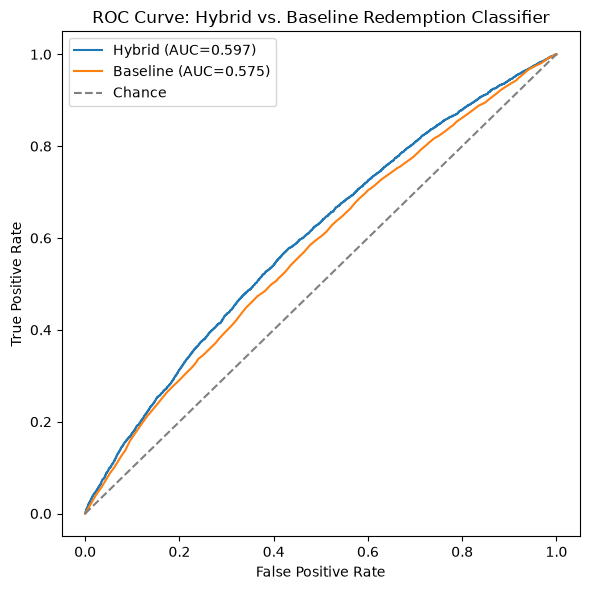

In [10]:
trc.plot_roc(y_test, p_hybrid_test, auc_hybrid, p_baseline_test, auc_baseline)

### Figure 2 — Calibration (Reliability) Diagram

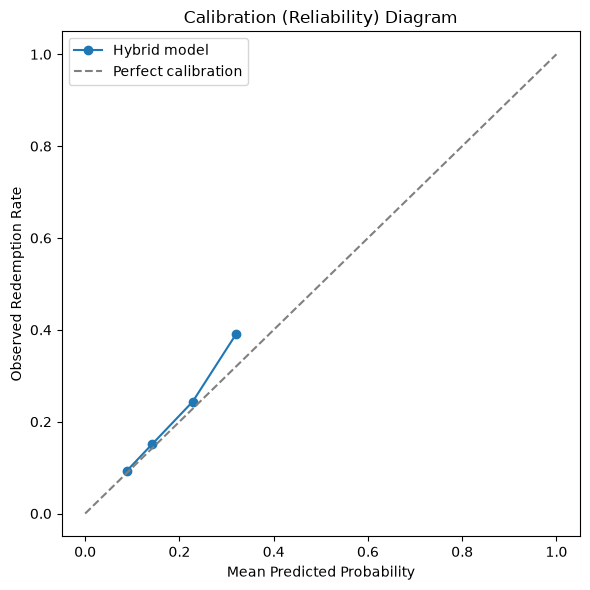

In [11]:
trc.plot_calibration(y_test, p_hybrid_test, 10)

### Figure 9 — Redemption Rate by Deal Type

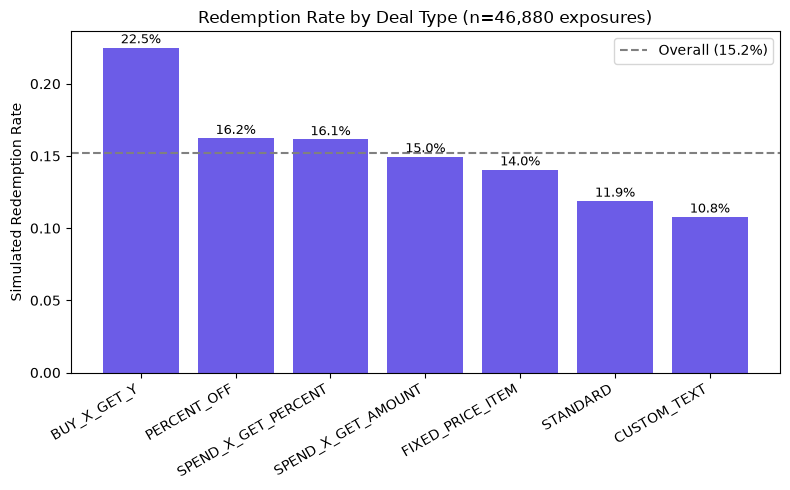

In [12]:
trc.plot_redemption_rate_by_type(exposures_df)

### Figure 10 — Business Category Distribution

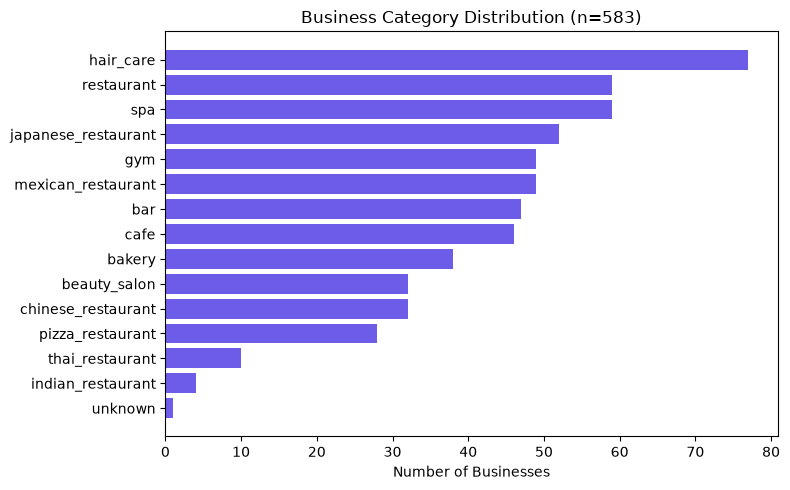

In [13]:
trc.plot_category_distribution(businesses)

### Figure 11 — Foot-Traffic Heatmap (Hour x Day-of-Week)

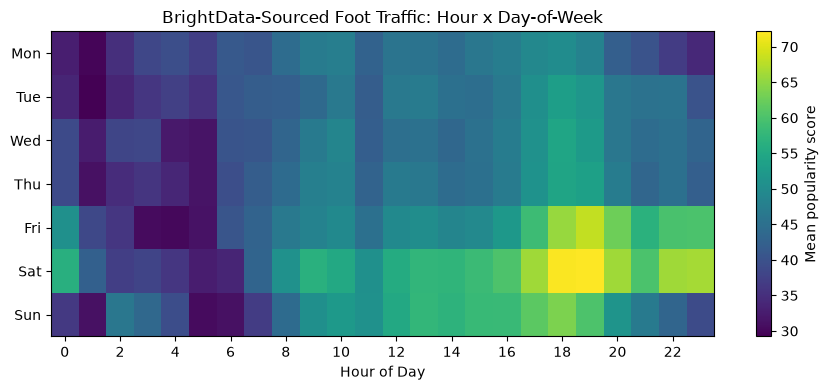

In [14]:
trc.plot_traffic_heatmap(popularity)

### Figure 12 — AUC-ROC by Model Variant

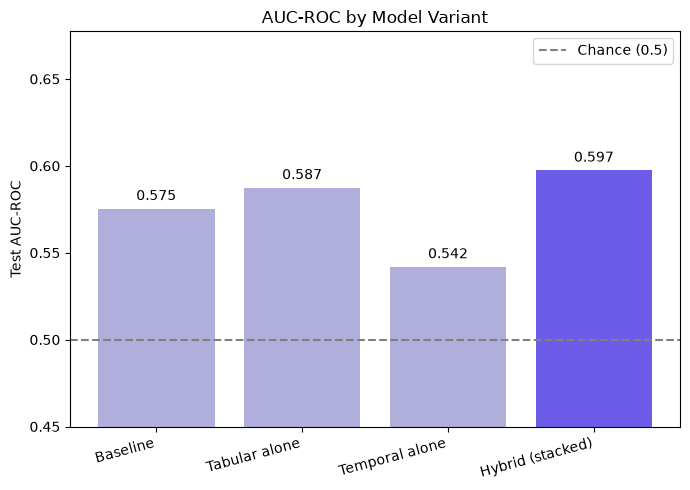

In [15]:
trc.plot_auc_comparison({"Baseline": auc_baseline, "Tabular alone": auc_tab, "Temporal alone": auc_temp, "Hybrid (stacked)": auc_hybrid})

### Figure 13 — Tabular Feature Importance

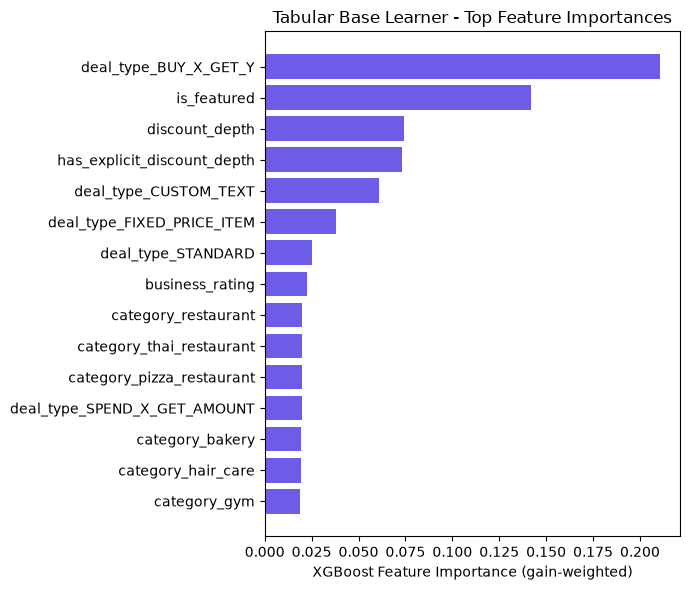

In [16]:
trc.plot_feature_importance(hybrid_models["tabular"], trc.TABULAR_FEATURES)

### Figure 14 — Predicted Probability Distribution by Outcome

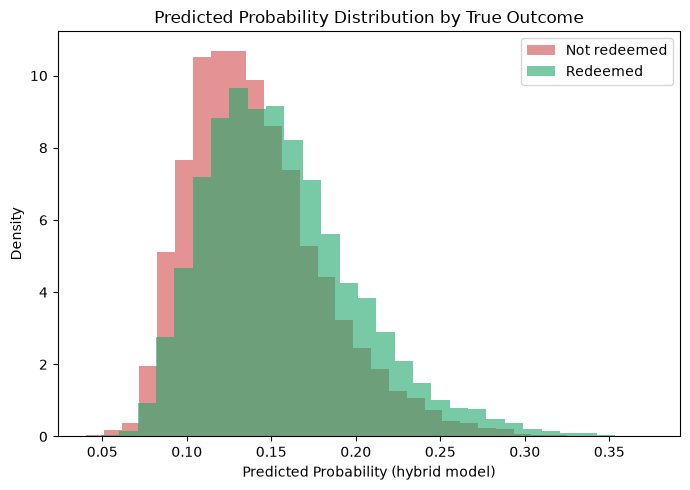

In [17]:
trc.plot_prediction_distribution(y_test, p_hybrid_test)

### Figure 15 — Precision@3 Distribution Across Businesses

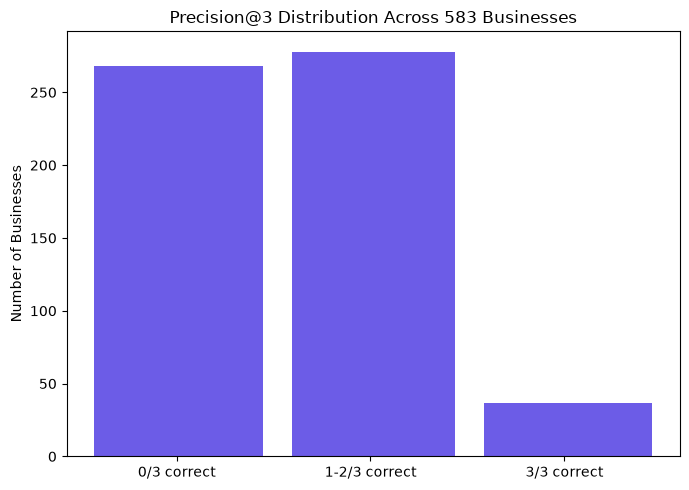

In [18]:
trc.plot_precision_at_3_distribution(prec3_scores)

## 9. Reproducibility Snapshot


In [19]:
import subprocess
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
key_pkgs = [l for l in freeze.splitlines() if l.split("==")[0].lower() in
            {"xgboost", "scikit-learn", "pandas", "numpy", "matplotlib", "sqlalchemy"}]
print("\n".join(key_pkgs))
print(f"\nPython: {sys.version.split()[0]}")

db.close()


matplotlib==3.11.0
numpy==2.4.1
pandas==3.0.0
scikit-learn==1.8.0
SQLAlchemy==2.0.46
xgboost==3.1.3

Python: 3.12.2


## Conclusion

The hybrid stacked classifier reaches test AUC-ROC **0.597** against a **0.575** baseline
(+0.022, measured directly above) with a nearly 40x calibration advantage
(ECE 0.009 vs. 0.341), and Precision@3 of **0.517** across all 583 businesses versus the
~0.43 expected value of a uniformly random top-3 ranking. Every number in this notebook was
computed live, in this run, from the pipeline functions in
`backend/scripts/train_redemption_classifier.py` — nothing here is copied from the report;
the report is generated *from* the same underlying, reproducible pipeline this notebook
demonstrates. See `research_report.md` / `research_report.pdf` for full discussion,
citations, and the application screenshots.
